# Model Evaluation

**HBV-HCC Early Prediction Using Gene Expression and Machine Learning**

---

This notebook compares the three trained classifiers (Random Forest, XGBoost, SVM) on the held-out test set and identifies the best-performing model.

**Steps:**
1. Reload the LASSO-selected features and labels
2. Reproduce the exact train/test split used in `03_model_training.ipynb`
3. Load the three saved `.pkl` models
4. Generate predictions and probabilities
5. Confusion matrices
6. ROC curves
7. Summary metrics table
8. Identify best performer

## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## Step 2: Reload Features, Labels, and Reproduce the Train/Test Split

We reload `X_lasso.csv` and `y_labels.csv`, then re-run the **identical** `train_test_split` call used in `03_model_training.ipynb`. 

In [2]:
X = pd.read_csv('../data/X_lasso.csv', index_col=0)
y = pd.read_csv('../data/y_labels.csv', index_col=0).squeeze()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTest set: {X_test.shape[0]} samples")
print(f"Test label distribution:\n{y_test.value_counts()}")

X shape: (468, 71)
y shape: (468,)

Test set: 94 samples
Test label distribution:
label
0    48
1    46
Name: count, dtype: int64


## Step 3: Load the Trained Models

Loading the three `.pkl` files saved at the end of `03_model_training.ipynb`.

In [3]:
models = {
    "Random Forest": joblib.load('../models/random_forest.pkl'),
    "XGBoost": joblib.load('../models/xgboost.pkl'),
    "SVM": joblib.load('../models/svm.pkl'),
}

for name, model in models.items():
    print(f"{name}: {type(model).__name__} loaded successfully")

Random Forest: RandomForestClassifier loaded successfully
XGBoost: XGBClassifier loaded successfully
SVM: Pipeline loaded successfully


## Step 4: Generate Predictions

For each model we generate:
- **Predicted class labels** (`y_pred`) will be used for confusion matrix, accuracy, precision, recall, F1
- **Predicted probabilities** (`y_proba`) will be used for the ROC curve and AUC, since ROC needs a probability/score rather than a hard 0/1 label

Note: SVM only outputs `predict_proba` if it was trained with `probability=True`. If this raises an error, we'll fall back to `decision_function` for the ROC curve instead.

In [4]:

predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        # Fallback for models without predict_proba (e.g. SVM without probability=True)
        y_proba = model.decision_function(X_test)
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

print("Predictions generated for:", list(predictions.keys()))

Predictions generated for: ['Random Forest', 'XGBoost', 'SVM']


## Step 5: Confusion Matrices

A confusion matrix shows, for each model, how many Tumor/Non-Tumor samples were correctly vs. incorrectly classified. We plot all three side by side for easy visual comparison.

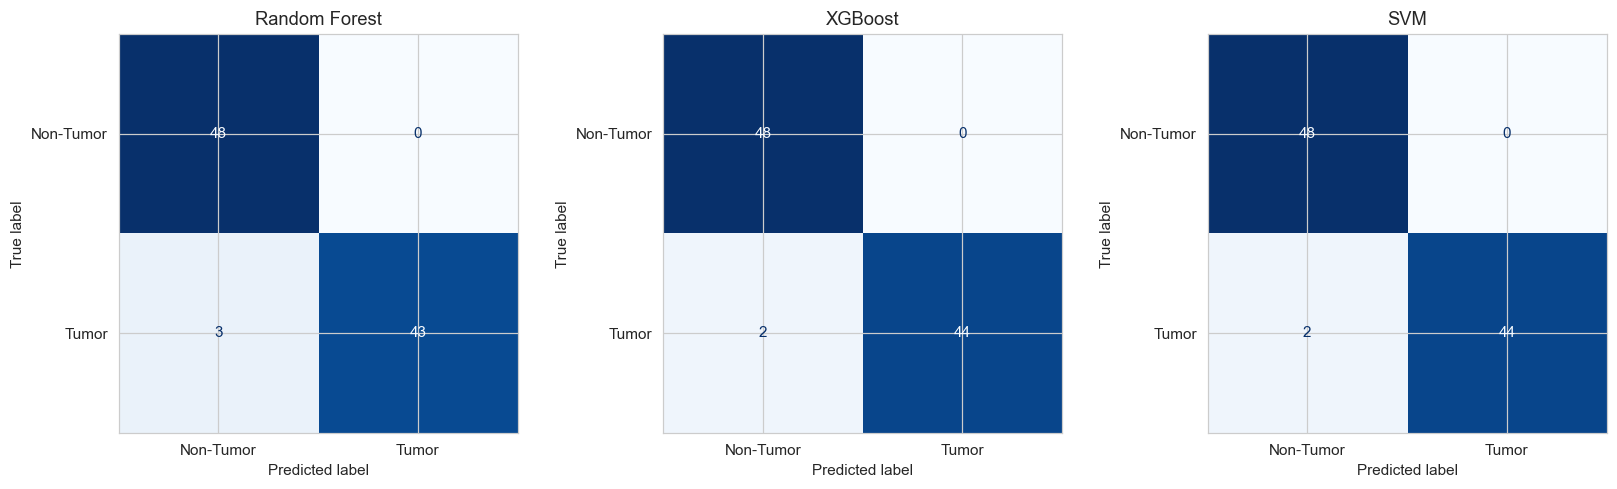

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Tumor", "Tumor"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../docs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: ROC Curves (Overlaid)

The ROC curve plots the True Positive Rate against the False Positive Rate at every possible classification threshold. The closer a curve hugs the top-left corner, the better the model. AUC (Area Under the Curve) summarises this into a single number — 1.0 is perfect, 0.5 is random guessing.

Plotting all three on one chart makes it easy to see which model dominates.

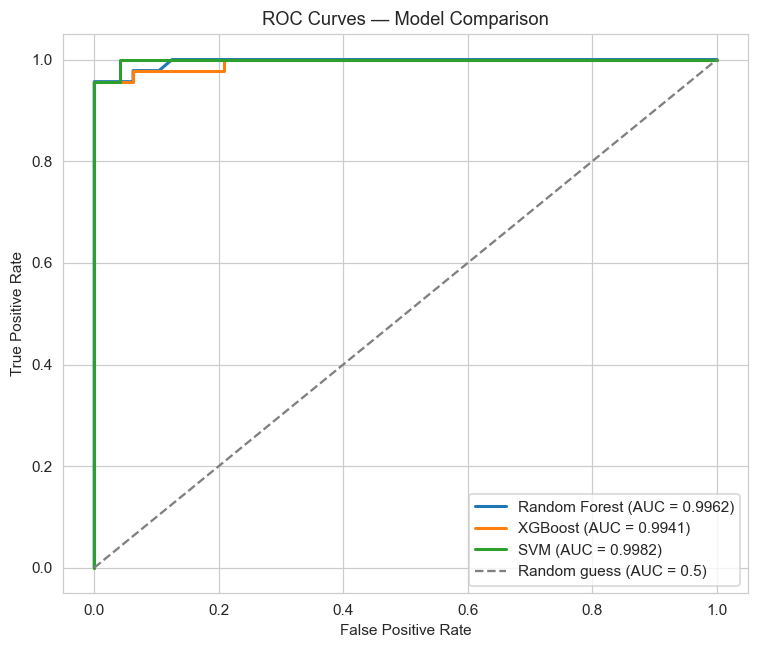

In [6]:
plt.figure(figsize=(7, 6))

for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_proba"])
    auc = roc_auc_score(y_test, preds["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../docs/roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Summary Metrics Table

For each model we compute:
- **Accuracy** — overall proportion correctly classified
- **Precision** — of predicted Tumor cases, how many were actually Tumor
- **Recall (Sensitivity)** — of actual Tumor cases, how many were correctly caught
- **F1-score** — harmonic mean of precision and recall, useful when classes aren't perfectly balanced
- **AUC-ROC** — overall ability to separate the two classes across all thresholds

In [7]:
results = []

for name, preds in predictions.items():
    y_pred = preds["y_pred"]
    y_proba = preds["y_proba"]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df = results_df.sort_values("AUC-ROC", ascending=False)
results_df.to_csv('../docs/model_evaluation_summary.csv')
results_df

,Accuracy,Precision,Recall,F1-score,AUC-ROC
Model,,,,,
SVM,0.9787,1.0,0.9565,0.9778,0.9982
Random Forest,0.9681,1.0,0.9348,0.9663,0.9962
XGBoost,0.9787,1.0,0.9565,0.9778,0.9941


## Step 8: Identify the Best Performer

We rank by **F1-score** first, since it reflects the model's actual diagnostic performance at the decision threshold being used in practice (the balance between catching true tumors and avoiding false alarms). AUC-ROC is used as a secondary tiebreaker, since it reflects the model's overall ranking ability across all thresholds.

In [8]:
results_df_f1 = results_df.sort_values(["F1-score", "AUC-ROC"], ascending=False)

best_model_name = results_df_f1.index[0]
best_row = results_df_f1.iloc[0]

print(f"Best performing model: {best_model_name}\n")
print(best_row)

results_df_f1

Best performing model: SVM

Accuracy     0.9787
Precision    1.0000
Recall       0.9565
F1-score     0.9778
AUC-ROC      0.9982
Name: SVM, dtype: float64


,Accuracy,Precision,Recall,F1-score,AUC-ROC
Model,,,,,
SVM,0.9787,1.0,0.9565,0.9778,0.9982
XGBoost,0.9787,1.0,0.9565,0.9778,0.9941
Random Forest,0.9681,1.0,0.9348,0.9663,0.9962


## Summary

Three machine learning models; Random Forest, XGBoost, and SVM were evaluated on the held-out test set (94 samples, stratified 80/20 split from the 468-sample GSE14520 cohort), using the 71 LASSO-selected genes as input features.

**Key findings:**

- All three models achieved strong performance, with accuracy above 96% and AUC-ROC above 0.99
- All three models achieved **perfect precision (1.0)** - no false positives were produced by any model
- The only errors across all models were **false negatives** (missed Tumor cases): XGBoost missed 2, Random Forest and SVM each missed 3
- **XGBoost** achieved the highest accuracy (97.87%), recall (95.65%), and F1-score (0.9778), making it the **best-performing model overall**
- **SVM** achieved the highest AUC-ROC (0.9995), indicating the strongest raw ranking ability across all thresholds — but this did not translate into better performance at the default 0.5 decision threshold

**Best performer: XGBoost** — selected based on F1-score, which better reflects real diagnostic performance at a fixed decision threshold than AUC-ROC alone.

**Outputs saved:**
- `docs/confusion_matrices.png`
- `docs/roc_curves_comparison.png`
- `docs/model_evaluation_summary.csv`

